# **Data Loading and Cleaning**

In [71]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/gowrishankarp/newspaper-text-summarization-cnn-dailymail/cnn_dailymail/validation.csv
/kaggle/input/datasets/gowrishankarp/newspaper-text-summarization-cnn-dailymail/cnn_dailymail/train.csv
/kaggle/input/datasets/gowrishankarp/newspaper-text-summarization-cnn-dailymail/cnn_dailymail/test.csv


In [72]:
import os, sys, json, warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 80)

DATA_DIR = "/content"
OUTPUT_DIR = "clean_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Data dir   : {os.path.abspath(DATA_DIR)}")
print(f"Output dir : {os.path.abspath(OUTPUT_DIR)}")

Data dir   : /content
Output dir : /kaggle/working/clean_data


## Load & Raw Data Exploration

In [73]:
DATA_DIR = "/kaggle/input/datasets/gowrishankarp/newspaper-text-summarization-cnn-dailymail/cnn_dailymail"
splits = ["train", "validation", "test"]
raw = {}
for s in splits:
    path = os.path.join(DATA_DIR, f"{s}.csv")
    raw[s] = pd.read_csv(path, on_bad_lines='skip', engine='python')
    print(f"[{s:>10}]  rows={len(raw[s]):>7,}  cols={list(raw[s].columns)}")

[     train]  rows=287,113  cols=['id', 'article', 'highlights']
[validation]  rows= 13,368  cols=['id', 'article', 'highlights']
[      test]  rows= 11,490  cols=['id', 'article', 'highlights']


In [74]:
raw["train"].head(3)

,id,article,highlights
0,0001d1afc246a7964130f43ae940af6bc6c57f01,"By . Associated Press . PUBLISHED: . 14:11 EST, 25 October 2013 . | . UPDATE...","Bishop John Folda, of North Dakota, is taking time off after being diagnosed..."
1,0002095e55fcbd3a2f366d9bf92a95433dc305ef,(CNN) -- Ralph Mata was an internal affairs lieutenant for the Miami-Dade Po...,Criminal complaint: Cop used his role to help cocaine traffickers .\nRalph M...
2,00027e965c8264c35cc1bc55556db388da82b07f,A drunk driver who killed a young woman in a head-on crash while checking hi...,"Craig Eccleston-Todd, 27, had drunk at least three pints before driving car ..."


In [75]:
raw["train"].dtypes

id            object
article       object
highlights    object
dtype: object

In [76]:
null_summary = pd.DataFrame({
    s: raw[s].isnull().sum() for s in splits
}).T
print("── Null counts ──")
print(null_summary)

── Null counts ──
            id  article  highlights
train        0        0           0
validation   0        0           0
test         0        0           0


In [77]:
for s in splits:
    dupes = raw[s].duplicated(subset=["id"]).sum()
    print(f"[{s}] duplicate IDs: {dupes}")

[train] duplicate IDs: 0
[validation] duplicate IDs: 0
[test] duplicate IDs: 0


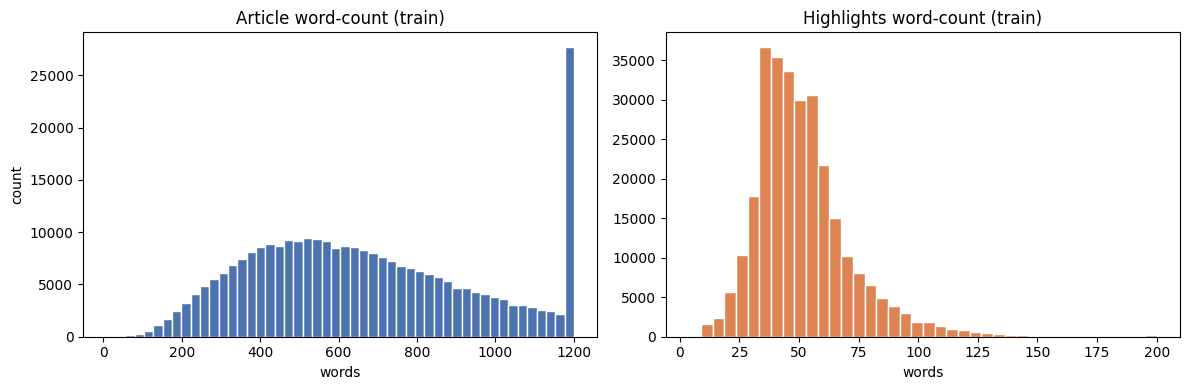

Article  — mean: 692  median: 632  max: 2347
Highlight— mean: 52  median: 48  max: 1296


In [78]:
train_art_wc  = raw["train"]["article"].dropna().str.split().str.len()
train_high_wc = raw["train"]["highlights"].dropna().str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_art_wc.clip(upper=1200), bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("Article word-count (train)")
axes[0].set_xlabel("words"); axes[0].set_ylabel("count")

axes[1].hist(train_high_wc.clip(upper=200), bins=40, color="#DD8452", edgecolor="white")
axes[1].set_title("Highlights word-count (train)")
axes[1].set_xlabel("words")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "word_count_distribution.png"), dpi=120)
plt.show()
print(f"Article  — mean: {train_art_wc.mean():.0f}  median: {train_art_wc.median():.0f}  max: {train_art_wc.max()}")
print(f"Highlight— mean: {train_high_wc.mean():.0f}  median: {train_high_wc.median():.0f}  max: {train_high_wc.max()}")

## Data Cleaning
| Step | Action |
|------|--------|
| 1 | Drop rows where `article` **or** `highlights` is null |
| 2 | Strip leading/trailing whitespace |
| 3 | Drop empty strings after strip |
| 4 | Deduplicate by `id` |
| 5 | Filter by word-count thresholds |

In [79]:
MIN_ARTICLE_WORDS    = 30
MIN_HIGHLIGHTS_WORDS = 5
MAX_ARTICLE_WORDS    = 2_000

def clean_df(df: pd.DataFrame, label: str = "") -> pd.DataFrame:
    tag = f"[{label}] " if label else ""
    orig = len(df)

    # 1. Drop nulls
    df = df.dropna(subset=["article", "highlights"])

    # 2. Strip whitespace
    df["article"]    = df["article"].str.strip()
    df["highlights"] = df["highlights"].str.strip()

    # 3. Drop empty strings
    df = df[(df["article"].str.len() > 0) & (df["highlights"].str.len() > 0)]

    # 4. Deduplicate
    df = df.drop_duplicates(subset=["id"])

    # 5. Word-count filter
    aw = df["article"].str.split().str.len()
    hw = df["highlights"].str.split().str.len()
    df = df[(aw >= MIN_ARTICLE_WORDS) & (aw <= MAX_ARTICLE_WORDS) & (hw >= MIN_HIGHLIGHTS_WORDS)]

    df = df.reset_index(drop=True)
    print(f"{tag}  {orig:>7,} → {len(df):>7,} rows  (removed {orig-len(df):,})")
    return df

clean = {}
print("Split          raw      clean    removed")
print("─" * 44)
for s in splits:
    clean[s] = clean_df(raw[s].copy(), label=s)


Split          raw      clean    removed
────────────────────────────────────────────
[train]   287,113 → 287,094 rows  (removed 19)
[validation]    13,368 →  13,368 rows  (removed 0)
[test]    11,490 →  11,490 rows  (removed 0)


## Verify Cleaned Data

In [80]:
verify = pd.DataFrame({
    s: {
        "rows":           len(clean[s]),
        "nulls_article":  clean[s]["article"].isnull().sum(),
        "nulls_highlights":clean[s]["highlights"].isnull().sum(),
        "duplicates":     clean[s].duplicated(subset=["id"]).sum(),
        "avg_art_words":  round(clean[s]["article"].str.split().str.len().mean(),1),
        "avg_high_words": round(clean[s]["highlights"].str.split().str.len().mean(),1),
    }
    for s in splits
}).T
verify

,rows,nulls_article,nulls_highlights,duplicates,avg_art_words,avg_high_words
train,287094.0,0.0,0.0,0.0,691.8,51.6
validation,13368.0,0.0,0.0,0.0,676.0,57.9
test,11490.0,0.0,0.0,0.0,683.5,55.0


## Visualization Of Cleaned Data

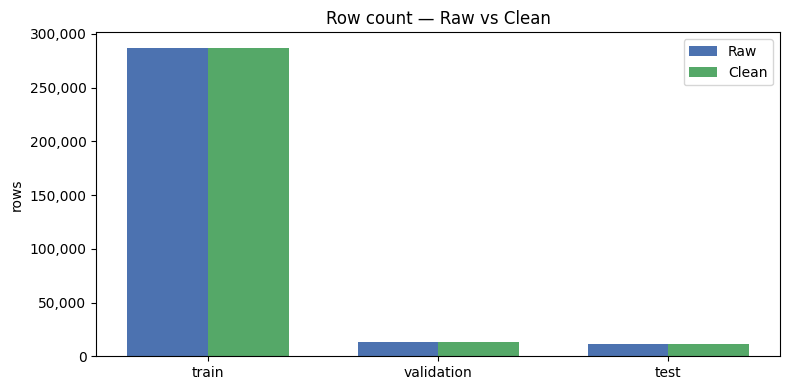

In [81]:
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(splits))
w = 0.35
ax.bar([i - w/2 for i in x], [len(raw[s]) for s in splits],  width=w, label="Raw",   color="#4C72B0")
ax.bar([i + w/2 for i in x], [len(clean[s]) for s in splits], width=w, label="Clean", color="#55A868")
ax.set_xticks(list(x)); ax.set_xticklabels(splits)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{int(v):,}"))
ax.set_title("Row count — Raw vs Clean"); ax.set_ylabel("rows"); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "raw_vs_clean.png"), dpi=120)
plt.show()


## Save Clean CSVs

In [82]:
for s in splits:
    out = os.path.join(OUTPUT_DIR, f"clean_{s}.csv")
    clean[s].to_csv(out, index=False)
    print(f"Saved → {out}  ({len(clean[s]):,} rows)")

Saved → clean_data/clean_train.csv  (287,094 rows)
Saved → clean_data/clean_validation.csv  (13,368 rows)
Saved → clean_data/clean_test.csv  (11,490 rows)


In [83]:
import pandas as pd

df = pd.read_csv("clean_data/clean_train.csv")
df.head()

,id,article,highlights
0,0001d1afc246a7964130f43ae940af6bc6c57f01,"By . Associated Press . PUBLISHED: . 14:11 EST, 25 October 2013 . | . UPDATE...","Bishop John Folda, of North Dakota, is taking time off after being diagnosed..."
1,0002095e55fcbd3a2f366d9bf92a95433dc305ef,(CNN) -- Ralph Mata was an internal affairs lieutenant for the Miami-Dade Po...,Criminal complaint: Cop used his role to help cocaine traffickers .\nRalph M...
2,00027e965c8264c35cc1bc55556db388da82b07f,A drunk driver who killed a young woman in a head-on crash while checking hi...,"Craig Eccleston-Todd, 27, had drunk at least three pints before driving car ..."
3,0002c17436637c4fe1837c935c04de47adb18e9a,(CNN) -- With a breezy sweep of his pen President Vladimir Putin wrote a new...,Nina dos Santos says Europe must be ready to accept sanctions will hurt both...
4,0003ad6ef0c37534f80b55b4235108024b407f0b,Fleetwood are the only team still to have a 100% record in Sky Bet League On...,"Fleetwood top of League One after 2-0 win at Scunthorpe .\nPeterborough, Bri..."


# **Data Preprocessing**

In [84]:
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [85]:
def fast_sentence_split(text):
    if not isinstance(text, str):
        return []
    return [s.strip() for s in text.split('.') if len(s.strip()) > 5]

In [86]:
def preprocess_text_fast(text):
    if not isinstance(text, str):
        return {"sentences": [], "tokens": [], "clean_text": ""}

    # clean first
    clean_text = text.lower()
    clean_text = re.sub(r'[^a-zA-Z\s]', '', clean_text)

    # fast sentence split (original text)
    sentences = fast_sentence_split(text)
    sentences = [s.strip() for s in sentences if len(s.split()) > 5]

    # tokenize cleaned text
    words = word_tokenize(clean_text)

    # remove stopwords
    words = [w for w in words if w not in stop_words and w.strip() != ""]

    return {
        "sentences": sentences,
        "tokens": words,
        "clean_text": " ".join(words)
    }

In [87]:
sample = df["article"].iloc[0]

result = preprocess_text_fast(sample)

print(result["sentences"][:3])
print(result["clean_text"][:200])

['The bishop of the Fargo Catholic Diocese in North Dakota has exposed potentially hundreds of church members in Fargo, Grand Forks and Jamestown to the hepatitis A virus in late September and early October', 'The state Health Department has issued an advisory of exposure for anyone who attended five churches and took communion', 'Bishop John Folda (pictured) of the Fargo Catholic Diocese in North Dakota has exposed potentially hundreds of church members in Fargo, Grand Forks and Jamestown to the hepatitis A']
associated press published est october updated est october bishop fargo catholic diocese north dakota exposed potentially hundreds church members fargo grand forks jamestown hepatitis virus late septe


In [88]:
from tqdm import tqdm
tqdm.pandas()

df = df.sample(5000, random_state=42)

df["processed"] = df["article"].progress_apply(preprocess_text_fast)

100%|██████████| 5000/5000 [00:09<00:00, 505.41it/s]


In [89]:

df["sentences"] = df["processed"].apply(lambda x: x["sentences"])
df["clean_text"] = df["processed"].apply(lambda x: x["clean_text"])

In [90]:
df.to_csv("clean_data/preprocessed_train_fast.csv", index=False)

In [91]:
print(df.shape)
print(df.columns)
print(df.head(1))

(5000, 6)
Index(['id', 'article', 'highlights', 'processed', 'sentences', 'clean_text'], dtype='object')
                                              id  \
161133  5c50fac1756719e1507a43cf0291ae61e049854c   

                                                                                article  \
161133  Former Sen. Rick Santorum, R-Pennsylvania, said this week that the growing t...   

                                                                             highlights  \
161133  Ex-Pennsylvania Sen. Rick Santorum says Nazi-like religious persecution poss...   

                                                                              processed  \
161133  {'sentences': ['Rick Santorum, R-Pennsylvania, said this week that the growi...   

                                                                              sentences  \
161133  [Rick Santorum, R-Pennsylvania, said this week that the growing threat towar...   

                                                          

In [92]:
print(df["processed"].iloc[0])

{'sentences': ['Rick Santorum, R-Pennsylvania, said this week that the growing threat towards American religious freedom by the government could lead to "Christian persecution," similar to how the oppression of Jews and Christians evolved over time under Nazi Germany', 'Arguing that the rise of the Nazi regime happened in a stable country where it was not expected, Santorum said that a similar situation could occur in the United States where, according to Santorum, religious liberties are "under direct assault" for the first time in history', '"Germany, prior to the Nazis getting there, was a very religious country," Santorum said in an interview with the Christian Post', 'It was a very sophisticated country', '" "The idea that you can have this kind of persecution take place over a period of ten years -- where you go from Christians -- Jews, obviously, but also Christians -- being not just persecuted but put to death -- was unfathomable," he said', '"It was unfathomable to them that (

In [93]:
print(df["processed"].isnull().sum())

0


In [94]:
df.sample(3)[["sentences", "clean_text"]]

,sentences,clean_text
264655,"[French lawyer Frank Samson, 47, who is set to play Napoleon, said the Frenc...",french lawyer frank samson set play napoleon said french dictator real hero ...
187170,[Fire chiefs are calling for safety messages to be displayed on electronic c...,fire chiefs calling safety messages displayed electronic cigarettes revealed...
30925,"[(Mashable) -- Sir Howard Stringer, CEO of Sony, accidentally told everyone ...",mashable sir howard stringer ceo sony accidentally told everyone world compa...


# **Feature Extraction**

# Feature Engineering — Text Summarization System

**Step 2 of the NLP Pipeline**

This notebook builds on the preprocessed data (`preprocessed_train_fast.csv`) and performs:

| # | Task | Method |
|---|------|--------|
| 1 | **TF-IDF Features** | `TfidfVectorizer` → sentence scores |
| 2 | **Word2Vec Embeddings** | Train on corpus → sentence vectors |
| 3 | **Sentence Importance Score** | Combine TF-IDF + embedding similarity |
| 4 | **Save Features** | Persist for use in downstream summarization steps |

## 0 — Imports & Configuration

In [95]:
import warnings, os, ast
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Install gensim if not already installed
try:
    from gensim.models import Word2Vec
except ImportError:
    !pip install gensim
    from gensim.models import Word2Vec

# directories
DATA_DIR   = 'clean_data'
OUTPUT_DIR = 'features'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✅  All imports OK')
print(f'   Data directory   : {os.path.abspath(DATA_DIR)}')
print(f'   Feature directory: {os.path.abspath(OUTPUT_DIR)}')


✅  All imports OK
   Data directory   : /kaggle/working/clean_data
   Feature directory: /kaggle/working/features


## 1 — Load Preprocessed Data

In [96]:
df = pd.read_csv(os.path.join(DATA_DIR, 'preprocessed_train_fast.csv'))

# parse 'sentences' column (stored as string repr of list)
def safe_parse_list(val):
    if isinstance(val, list):  return val
    try:                        return ast.literal_eval(val)
    except Exception:           return []

df['sentences'] = df['sentences'].apply(safe_parse_list)

# drop rows with empty sentences or clean_text
df = df[df['sentences'].map(len) > 0].reset_index(drop=True)
df = df[df['clean_text'].notna() & (df['clean_text'].str.strip() != '')].reset_index(drop=True)

print(f'Rows loaded : {len(df):,}')
print(f'Columns     : {list(df.columns)}')
df[['article', 'clean_text', 'sentences']].head(2)

Rows loaded : 5,000
Columns     : ['id', 'article', 'highlights', 'processed', 'sentences', 'clean_text']


,article,clean_text,sentences
0,"Former Sen. Rick Santorum, R-Pennsylvania, said this week that the growing t...",former sen rick santorum rpennsylvania said week growing threat towards amer...,"[Rick Santorum, R-Pennsylvania, said this week that the growing threat towar..."
1,David Cameron and Theresa May are locked in a battle to curb police stop and...,david cameron theresa may locked battle curb police stop search powers prime...,[David Cameron and Theresa May are locked in a battle to curb police stop an...


## 2 — Feature Extraction: TF-IDF

### 2.1  Corpus-level TF-IDF vocabulary
We fit a `TfidfVectorizer` on the full corpus of **cleaned texts**.  
This learns which words are **rare across articles** (high IDF) and therefore carry strong signal.

In [97]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=20_000,   # keep top 20k vocabulary terms
    ngram_range=(1, 2),    # unigrams + bigrams
    sublinear_tf=True,     # apply log(1 + tf) smoothing
    min_df=2               # ignore terms appearing in < 2 docs
)

# Fit on cleaned text corpus
tfidf_matrix = tfidf_vectorizer.fit_transform(df['clean_text'])

print(f'Vocabulary size : {len(tfidf_vectorizer.vocabulary_):,}')
print(f'TF-IDF matrix   : {tfidf_matrix.shape}  (docs × terms)')

Vocabulary size : 20,000
TF-IDF matrix   : (5000, 20000)  (docs × terms)


### 2.2  Sentence-level TF-IDF score

For each article we:
1. Split into individual sentences (already done in preprocessing).
2. Vectorize each sentence using the fitted vocabulary.
3. Compute the **mean TF-IDF weight** of the sentence as its importance score.

Higher score → sentence contains more distinctive / important keywords.

In [98]:
def score_sentences_tfidf(sentences, vectorizer):
    """
    Returns a list of TF-IDF importance scores, one per sentence.
    Score = mean of non-zero TF-IDF weights in that sentence.
    """
    if not sentences:
        return []

    # preprocess sentences the same way (lowercase, no punct)
    import re
    clean = [re.sub(r'[^a-zA-Z\s]', '', s.lower()) for s in sentences]

    try:
        mat = vectorizer.transform(clean)          # shape: (n_sents, vocab)
    except Exception:
        return [0.0] * len(sentences)

    # mean of non-zero entries per row
    scores = []
    for i in range(mat.shape[0]):
        row = mat.getrow(i)
        nz  = row.data
        scores.append(float(nz.mean()) if len(nz) > 0 else 0.0)

    return scores

# Apply to every article
from tqdm import tqdm
tqdm.pandas(desc='TF-IDF sentence scoring')

df['tfidf_scores'] = df['sentences'].progress_apply(
    lambda sents: score_sentences_tfidf(sents, tfidf_vectorizer)
)

# Sanity check on one article
idx = 0
print('\n── Sample article sentence scores ──')
for s, sc in zip(df['sentences'].iloc[idx][:5], df['tfidf_scores'].iloc[idx][:5]):
    print(f'  [{sc:.4f}]  {s[:80]}')

TF-IDF sentence scoring: 100%|██████████| 5000/5000 [00:13<00:00, 359.74it/s]


── Sample article sentence scores ──
  [0.1901]  Rick Santorum, R-Pennsylvania, said this week that the growing threat towards Am
  [0.1715]  Arguing that the rise of the Nazi regime happened in a stable country where it w
  [0.2806]  "Germany, prior to the Nazis getting there, was a very religious country," Santo
  [0.6692]  It was a very sophisticated country
  [0.2003]  " "The idea that you can have this kind of persecution take place over a period 


### 2.3  Visualise TF-IDF score distribution

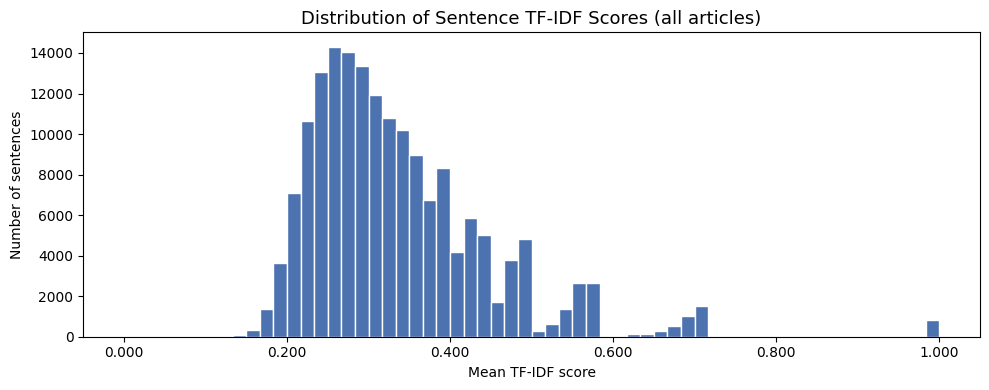

Score stats →  mean=0.3368  median=0.3109  max=1.0000


In [99]:
all_scores = [sc for row in df['tfidf_scores'] for sc in row]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_scores, bins=60, color='#4C72B0', edgecolor='white')
ax.set_title('Distribution of Sentence TF-IDF Scores (all articles)', fontsize=13)
ax.set_xlabel('Mean TF-IDF score')
ax.set_ylabel('Number of sentences')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tfidf_score_distribution.png'), dpi=120)
plt.show()

print(f'Score stats →  mean={np.mean(all_scores):.4f}  '
      f'median={np.median(all_scores):.4f}  '
      f'max={np.max(all_scores):.4f}')

## 3 — Feature Extraction: Word2Vec Embeddings

### 3.1  Train Word2Vec on the corpus

We train a **Skip-gram Word2Vec** model on the tokenised texts.  
Each word gets a dense 100-dimensional vector that encodes **semantic meaning**.

In [100]:
# Build list of token lists from clean_text column
from nltk.tokenize import word_tokenize

print('Tokenising corpus for Word2Vec training …')
token_corpus = [text.split() for text in df['clean_text'] if isinstance(text, str)]

print(f'  Documents : {len(token_corpus):,}')
print(f'  Avg tokens: {np.mean([len(t) for t in token_corpus]):.1f}')

# Train Word2Vec
w2v_model = Word2Vec(
    sentences=token_corpus,
    vector_size=100,   # embedding dimensions
    window=5,          # context window
    min_count=3,       # ignore words appearing < 3 times
    sg=1,              # 1 = Skip-gram, 0 = CBOW
    workers=4,
    epochs=5,
    seed=42
)

print(f'\n✅  Word2Vec trained')
print(f'   Vocabulary size : {len(w2v_model.wv):,} words')
print(f'   Embedding dims  : {w2v_model.vector_size}')

Tokenising corpus for Word2Vec training …
  Documents : 5,000
  Avg tokens: 378.9

✅  Word2Vec trained
   Vocabulary size : 37,651 words
   Embedding dims  : 100


### 3.2  Inspect the word vector space

A quick sanity-check — semantically similar words should appear close to each other.

In [101]:
probe_words = ['government', 'police', 'economy', 'president', 'report']

print('── Most similar words (Word2Vec) ──\n')
for word in probe_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        similar_str = ', '.join([f"{w} ({s:.2f})" for w, s in similar])
        print(f'  {word:>12} → {similar_str}')
    else:
        print(f'  {word:>12} → (not in vocabulary)')

── Most similar words (Word2Vec) ──

    government → governments (0.79), oppose (0.77), ceasefire (0.75), sovereignty (0.75), transitional (0.75)
        police → officers (0.83), detectives (0.74), authorities (0.66), officer (0.65), deputies (0.64)
       economy → recession (0.83), eurozone (0.79), unemployment (0.79), economic (0.78), gdp (0.78)
     president → barack (0.78), obama (0.78), presidents (0.70), biden (0.69), hollande (0.69)
        report → contributed (0.68), cnns (0.67), messia (0.63), hada (0.62), kassim (0.62)


### 3.3  Sentence embeddings via mean-pooling

We represent each sentence as the **average Word2Vec vector** of its words.  
Words not in the vocabulary are skipped.

In [102]:
def sentence_to_vector(sentence: str, model: Word2Vec) -> np.ndarray:
    """
    Mean-pool Word2Vec vectors for all known words in the sentence.
    Returns a zero vector if no words are in the vocabulary.
    """
    import re
    tokens = re.sub(r'[^a-zA-Z\s]', '', sentence.lower()).split()
    vecs   = [model.wv[w] for w in tokens if w in model.wv]
    if vecs:
        return np.mean(vecs, axis=0)          # shape: (vector_size,)
    return np.zeros(model.vector_size)


def get_sentence_embeddings(sentences, model):
    """Return a list of embedding vectors, one per sentence."""
    return [sentence_to_vector(s, model) for s in sentences]


# Apply — store as list of numpy arrays per document
tqdm.pandas(desc='Word2Vec sentence embeddings')

df['sentence_embeddings'] = df['sentences'].progress_apply(
    lambda sents: get_sentence_embeddings(sents, w2v_model)
)

# Show embedding for the first sentence of the first article
emb_sample = df['sentence_embeddings'].iloc[0][0]
print(f'Embedding shape : {emb_sample.shape}')
print(f'Sample values   : {emb_sample[:8].round(4)}')

Word2Vec sentence embeddings: 100%|██████████| 5000/5000 [00:07<00:00, 642.80it/s]

Embedding shape : (100,)
Sample values   : [ 0.1544  0.0009 -0.107   0.164  -0.1581  0.2665  0.1391  0.2082]


### 3.4  Centroid similarity score

We compute the **document centroid** (mean of all sentence embeddings) and score each sentence by its **cosine similarity** to that centroid.  
Sentences that are *most representative* of the overall document get higher scores.

In [103]:
def centroid_similarity_scores(sentence_embeddings):
    """
    Compute cosine similarity of each sentence embedding to the document centroid.
    """
    if not sentence_embeddings:
        return []

    matrix   = np.vstack(sentence_embeddings)           # (n_sents, dim)
    centroid = matrix.mean(axis=0, keepdims=True)       # (1, dim)

    sims = cosine_similarity(matrix, centroid).flatten()  # (n_sents,)
    return sims.tolist()


tqdm.pandas(desc='Centroid similarity scoring')

df['embedding_scores'] = df['sentence_embeddings'].progress_apply(
    centroid_similarity_scores
)

# Sanity check
idx = 1
print('\n── Centroid similarity scores (sample) ──')
for s, sc in zip(df['sentences'].iloc[idx][:5], df['embedding_scores'].iloc[idx][:5]):
    print(f'  [{sc:.4f}]  {s[:80]}')

Centroid similarity scoring: 100%|██████████| 5000/5000 [00:02<00:00, 2246.70it/s]


── Centroid similarity scores (sample) ──
  [0.9057]  David Cameron and Theresa May are locked in a battle to curb police stop and sea
  [0.9034]  The Prime Minister and Home Secretary are split over plans to limit the use of t
  [0.9543]  Mrs May has warned the excessive use of stop and search is a ‘dreadful waste of 
  [0.9453]  Clash: David Cameron fears Theresa May's plans to rein in the use of stop and se
  [0.9014]  In a damning report last year, Her Majesty’s Chief Inspector of Constabulary fou


## 4 — Combined Sentence Importance Score

We merge the two signals into a single **importance score** per sentence:

$$\text{importance}(s_i) = \alpha \cdot \text{TF-IDF}(s_i) + (1-\alpha) \cdot \text{EmbeddingSim}(s_i)$$

- **TF-IDF score** → sentence contains key distinctive terms  
- **Embedding similarity** → sentence is representative of the document's topic

We normalise both signals to [0, 1] before combining.

In [104]:
ALPHA = 0.3   # weight for TF-IDF; (1-ALPHA) goes to embedding similarity

def normalize(scores):
    """Min-max normalise a list of scores to [0, 1]."""
    arr = np.array(scores, dtype=float)
    rng = arr.max() - arr.min()
    if rng == 0:
        return np.zeros_like(arr).tolist()
    return ((arr - arr.min()) / rng).tolist()


def combined_importance(tfidf_scores, embedding_scores, alpha=ALPHA):
    """
    Weighted combination of normalised TF-IDF and embedding-centroid scores.
    """
    n = len(tfidf_scores)
    if n == 0:
        return []

    t_norm = normalize(tfidf_scores)
    e_norm = normalize(embedding_scores) if embedding_scores else [0.0] * n

    return [alpha * t + (1 - alpha) * e
            for t, e in zip(t_norm, e_norm)]


df['importance_scores'] = df.apply(
    lambda row: combined_importance(row['tfidf_scores'], row['embedding_scores']),
    axis=1
)

print('✅  Combined importance scores computed')
print(f'   Alpha (TF-IDF weight)          : {ALPHA}')
print(f'   (1-Alpha) (Embedding weight)   : {1 - ALPHA}')

✅  Combined importance scores computed
   Alpha (TF-IDF weight)          : 0.3
   (1-Alpha) (Embedding weight)   : 0.7


## 5 — Demonstration: Top-scored Sentences per Article

Let's visually verify that our scoring picks **informative, high-value sentences**.

In [105]:
def get_top_sentences(sentences, importance_scores, top_n=3):
    """
    Return the top-N sentences by importance score,
    preserving their original document order.
    """
    if not sentences:
        return []

    ranked = sorted(
        enumerate(importance_scores),
        key=lambda x: x[1],
        reverse=True
    )[:top_n]

    # restore original order
    chosen_idx = sorted([i for i, _ in ranked])
    return [sentences[i] for i in chosen_idx]


for sample_idx in [0, 1, 2]:
    sents  = df['sentences'].iloc[sample_idx]
    scores = df['importance_scores'].iloc[sample_idx]
    top3   = get_top_sentences(sents, scores, top_n=3)

    print(f'\n{'='*70}')
    print(f'Article {sample_idx} | {len(sents)} sentences total')
    print(f'{'─'*70}')
    print('Original (first 200 chars):')
    print(' ', str(df['article'].iloc[sample_idx])[:200])
    print('\nTop-3 important sentences (feature-scored):')
    for i, s in enumerate(top3, 1):
        print(f'  [{i}] {s}')


Article 0 | 16 sentences total
──────────────────────────────────────────────────────────────────────
Original (first 200 chars):
  Former Sen. Rick Santorum, R-Pennsylvania, said this week that the growing threat towards American religious freedom by the government could lead to "Christian persecution," similar to how the oppress

Top-3 important sentences (feature-scored):
  [1] " While the former presidential candidate did acknowledge that persecution in America is "fairly mild" compared to what's going on in other parts of the world, he warned that it is still dangerous because "it's something that grows over time
  [2] " "It starts in a gradual erosion," Santorum said
  [3] "You either conform to what the government says you have to believe in, or you're going to lose certain privileges

Article 1 | 26 sentences total
──────────────────────────────────────────────────────────────────────
Original (first 200 chars):
  David Cameron and Theresa May are locked in a battle to curb po

## 6 — Per-Sentence Feature Table

Build an **exploded** sentence-level DataFrame for detailed inspection and downstream use.

In [106]:
rows = []
for doc_id, row in df.iterrows():
    for rank, (sent, tsc, esc, isc) in enumerate(
        zip(row['sentences'],
            row['tfidf_scores'],
            row['embedding_scores'],
            row['importance_scores'])):
        rows.append({
            'doc_id'          : doc_id,
            'sentence_rank'   : rank,
            'sentence'        : sent,
            'tfidf_score'     : round(tsc,  5),
            'embedding_score' : round(esc,  5),
            'importance_score': round(isc,  5),
        })

sent_df = pd.DataFrame(rows)
print(f'Sentence table shape: {sent_df.shape}')
sent_df.head(8)

Sentence table shape: (172237, 6)


,doc_id,sentence_rank,sentence,tfidf_score,embedding_score,importance_score
0,0,0,"Rick Santorum, R-Pennsylvania, said this week that the growing threat toward...",0.19013,0.93956,0.67010
1,0,1,Arguing that the rise of the Nazi regime happened in a stable country where ...,0.17146,0.94093,0.66488
2,0,2,"""Germany, prior to the Nazis getting there, was a very religious country,"" S...",0.28055,0.92574,0.66377
3,0,3,It was a very sophisticated country,0.66921,0.78983,0.30000
4,0,4,""" ""The idea that you can have this kind of persecution take place over a per...",0.20035,0.94654,0.70695
5,0,5,"""It was unfathomable to them that (in) a country like this, this could happen",0.39849,0.87405,0.50743
6,0,6,""" While the former presidential candidate did acknowledge that persecution i...",0.20533,0.94891,0.72042
7,0,7,""" ""It starts in a gradual erosion,"" Santorum said",0.44862,0.92139,0.74592


## 7 — Score Correlation Analysis

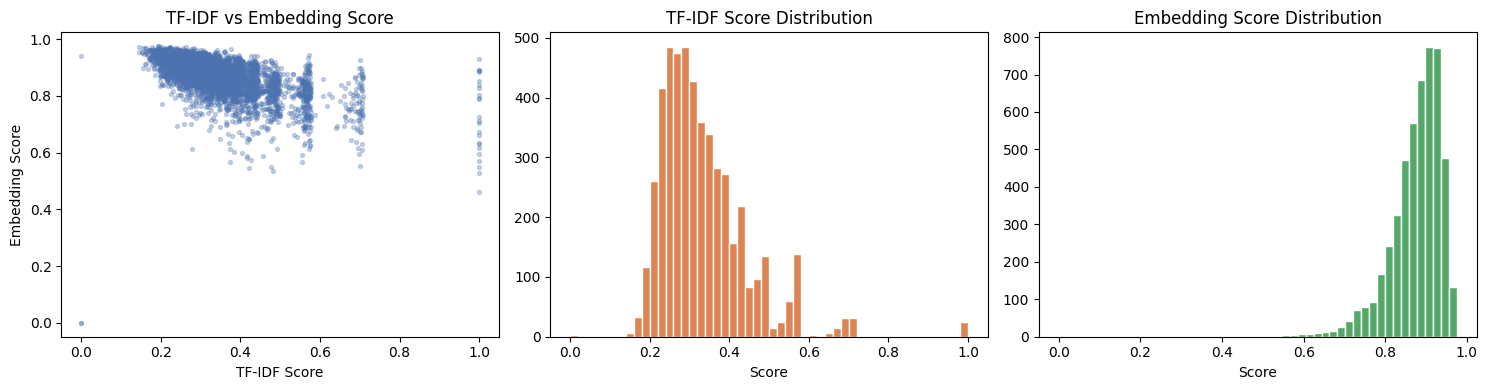


Correlation matrix:
                  tfidf_score  embedding_score  importance_score
tfidf_score             1.000           -0.595            -0.214
embedding_score        -0.595            1.000             0.735
importance_score       -0.214            0.735             1.000


In [107]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sample for speed
sample = sent_df.sample(min(5000, len(sent_df)), random_state=42)

axes[0].scatter(sample['tfidf_score'], sample['embedding_score'],
                alpha=0.3, s=8, color='#4C72B0')
axes[0].set_xlabel('TF-IDF Score');  axes[0].set_ylabel('Embedding Score')
axes[0].set_title('TF-IDF vs Embedding Score')

axes[1].hist(sample['tfidf_score'],     bins=50, color='#DD8452', edgecolor='white')
axes[1].set_title('TF-IDF Score Distribution');  axes[1].set_xlabel('Score')

axes[2].hist(sample['embedding_score'], bins=50, color='#55A868', edgecolor='white')
axes[2].set_title('Embedding Score Distribution');  axes[2].set_xlabel('Score')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_score_analysis.png'), dpi=120)
plt.show()

corr = sample[['tfidf_score', 'embedding_score', 'importance_score']].corr()
print('\nCorrelation matrix:')
print(corr.round(3))

## 8 — Save Features

In [108]:
import pickle, json

# 8a. Document-level features (with lists) → pickle
doc_features = df[['article', 'highlights', 'clean_text',
                    'sentences', 'tfidf_scores',
                    'embedding_scores', 'importance_scores']].copy()

doc_features.to_pickle(os.path.join(OUTPUT_DIR, 'doc_features.pkl'))
print('✅  Saved  →  features/doc_features.pkl')

# 8b. Sentence-level feature table → CSV
sent_df.to_csv(os.path.join(OUTPUT_DIR, 'sentence_features.csv'), index=False)
print('✅  Saved  →  features/sentence_features.csv')

# 8c. TF-IDF vectorizer → pickle
with open(os.path.join(OUTPUT_DIR, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print('✅  Saved  →  features/tfidf_vectorizer.pkl')

# 8d. Word2Vec model
w2v_model.save(os.path.join(OUTPUT_DIR, 'word2vec.model'))
print('✅  Saved  →  features/word2vec.model')

# 8e. Config metadata
config = {
    'alpha'            : ALPHA,
    'tfidf_max_features': 20_000,
    'tfidf_ngram_range': [1, 2],
    'w2v_vector_size'  : w2v_model.vector_size,
    'w2v_window'       : 5,
    'w2v_min_count'    : 3,
    'w2v_sg'           : 1,
    'docs_processed'   : len(df)
}
with open(os.path.join(OUTPUT_DIR, 'feature_config.json'), 'w') as f:
    json.dump(config, f, indent=2)
print('✅  Saved  →  features/feature_config.json')

✅  Saved  →  features/doc_features.pkl
✅  Saved  →  features/sentence_features.csv
✅  Saved  →  features/tfidf_vectorizer.pkl
✅  Saved  →  features/word2vec.model
✅  Saved  →  features/feature_config.json


## 9 — Summary

| Feature | Description | Saved as |
|---------|-------------|----------|
| **TF-IDF matrix** | Corpus-level term weights (20k vocab, 1–2 grams) | `tfidf_vectorizer.pkl` |
| **TF-IDF sentence score** | Mean TF-IDF weight per sentence | inside `doc_features.pkl` |
| **Word2Vec embeddings** | 100-dim skip-gram trained on corpus | `word2vec.model` |
| **Embedding similarity** | Cosine similarity to document centroid | inside `doc_features.pkl` |
| **Combined importance** | α·TF-IDF + (1-α)·EmbSim, both normalised | `doc_features.pkl` & `sentence_features.csv` |


# **BaseLine Model**

In [109]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [110]:
def summarize_baseline(sentences, importance_scores, top_n=3, show_rank=True):
    if not sentences:
        return ""

    #sort by scores
    ranked = sorted(
        enumerate(importance_scores),
        key=lambda x:x[1],
        reverse=True

    )[:top_n]

    if show_rank:
      print("\n Sentences ranking")

      for rank,(idx,score) in enumerate(ranked,1):
          print(f"Rank {rank}")
          print(f"Score :{score:.4f}")
          print(f"Sentence :{sentences[idx]}")
          print("-"*70)




    indices= sorted([i for i,_ in ranked])  #to order them like their order in dovument
    bs_summary=" ".join([sentences[i] for i in indices])
    return bs_summary

In [111]:
#Show the high ranked senntences
row=df.iloc[0]
sentences=row["sentences"]
importance_scores=row["importance_scores"]

bs_summary = summarize_baseline(
    sentences,
    importance_scores,
    top_n=3
)

print(bs_summary)


 Sentences ranking
Rank 1
Score :0.7459
Sentence :" "It starts in a gradual erosion," Santorum said
----------------------------------------------------------------------
Rank 2
Score :0.7338
Sentence :"You either conform to what the government says you have to believe in, or you're going to lose certain privileges
----------------------------------------------------------------------
Rank 3
Score :0.7204
Sentence :" While the former presidential candidate did acknowledge that persecution in America is "fairly mild" compared to what's going on in other parts of the world, he warned that it is still dangerous because "it's something that grows over time
----------------------------------------------------------------------
" While the former presidential candidate did acknowledge that persecution in America is "fairly mild" compared to what's going on in other parts of the world, he warned that it is still dangerous because "it's something that grows over time " "It starts in a gradual

In [112]:
df["baseline_summary"]= df.apply(
    lambda row:summarize_baseline(
        row["sentences"],
        row["importance_scores"],
        top_n=3

    ),
    axis=1

)


 Sentences ranking
Rank 1
Score :0.7459
Sentence :" "It starts in a gradual erosion," Santorum said
----------------------------------------------------------------------
Rank 2
Score :0.7338
Sentence :"You either conform to what the government says you have to believe in, or you're going to lose certain privileges
----------------------------------------------------------------------
Rank 3
Score :0.7204
Sentence :" While the former presidential candidate did acknowledge that persecution in America is "fairly mild" compared to what's going on in other parts of the world, he warned that it is still dangerous because "it's something that grows over time
----------------------------------------------------------------------

 Sentences ranking
Rank 1
Score :0.7000
Sentence :Mrs May has warned the excessive use of stop and search is a ‘dreadful waste of police time’ and fears young black men being disproportionately targeted risks undermining public confidence in the police
-------------

In [113]:
#to check the difference in size of baseline and improved one

df["compression_baseline"]=df.apply(
    lambda r:len(r["baseline_summary"].split()) /len(r["article"].split()),
    axis=1
)


print("Baseline avg compression:",df["compression_baseline"].mean())


Baseline avg compression: 0.1223793203659495


In [114]:
!pip install tqdm
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

tqdm.pandas()

model = SentenceTransformer(
    'all-MiniLM-L6-v2',
    device='cpu'
)

def semantic_score(row):

    #change to vectors
    orig=model.encode(row["article"])
    summary=model.encode(row["baseline_summary"])
    return cosine_similarity([orig],[summary])[0][0]

df["semantic_score"]=df.progress_apply(semantic_score,axis=1)
print("Semantic avg:",df["semantic_score"].mean())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 5000/5000 [05:32<00:00, 15.03it/s]

Semantic avg: 0.68643963


In [115]:
#test
def test_baseline_sample(df,index=0):
    row =df.iloc[index]
    print(f"Article(first 400 chars):\n{row['article'][:400]}...\n")

    print("Basline Summary:\n")
    print(row["baseline_summary"])

    print(f"Compression:{row['compression_baseline']:.4f}")
    print(f"Semantic Similarity:{row['semantic_score']:.4f}")


In [116]:
import random
for i in random.sample(range(len(df)),3):
     test_baseline_sample(df,i)

Article(first 400 chars):
If the Steffon Armitage deal to Bath does go through, I would applaud the RFU and Stuart Lancaster for any part they may have had in making this happen. It sends out a strong message that, in this World Cup season, England will not compromise. There will be no ‘what-ifs’ or excuses. England will do everything they can to win the World Cup. If you do that, and ultimately there is disappointment bec...

Basline Summary:

There will be no ‘what-ifs’ or excuses As this story has unfolded I found it totally unacceptable that potentially we could have been facing a situation in which Armitage was not only unavailable for England selection but could even line up against them for France in a big World Cup game! The truth is Armitage may not get picked as an England starter — he is going to find it very tough — but a player of his quality has to be in the squad pushing hard for selection, challenging all the others I see no reason why a player looking to better himself

### Save Baseline Model PKI and model



In [117]:
import pickle
import os

try:
  from gensim.models import Word2Vec
except ImportError:
  !pip install gensim
  from gensim.models import Word2Vec

OUTPUT_DIR='features'

#load tf-idf vectorizer
with open(os.path.join(OUTPUT_DIR,'tfidf_vectorizer.pkl'),'rb') as f:
    loaded_tfidf_vectorizer=pickle.load(f)


#load word2vec model
loaded_w2v_model=Word2Vec.load(os.path.join(OUTPUT_DIR,'word2vec.model'))

print("loaded TF-IDF vectorizer and Word2Vec model")

loaded TF-IDF vectorizer and Word2Vec model


In [118]:
#try sample with this loaded models

if 'df' not in locals():
  print("df not found ,ensure previous data loaded.")
  sample_article_text="This is a sample article for demonstration. It has multiple sentences. We will try to summarize it. The TF-IDF and Word2Vec models are used to determine sentence importance. This helps in extracting key sentences."

  sample_sentences=[s.strip() for s in sample_article_text.split('.') if len (s.strip())>5]
  sample_clean_text=' '.join(nltk.word_tokenize(re.sub(r'[^a-zA-Z\s]','',sample_article_text.lower())))

else:
  sample_row=df.iloc[0]
  sample_article_text=sample_row['article']
  sample_sentences=sample_row['sentences']
  sample_clean_text=sample_row['clean_text']


#tf-idf
tfidf_scores_new=score_sentences_tfidf(sample_sentences,loaded_tfidf_vectorizer)

#w2v &centroid similarity
sentence_embeddings_new=get_sentence_embeddings(sample_sentences,loaded_w2v_model)
embedding_scores_new=centroid_similarity_scores(sentence_embeddings_new)

#combined scores
importance_scores_new=combined_importance(tfidf_scores_new,embedding_scores_new,alpha=ALPHA)


#summary
baseline_summary_new=summarize_baseline(sample_sentences,importance_scores_new,top_n=3)

print("\n Sample article(first 500 letters) ")
print(sample_article_text[:500],"...") #to fill in when no space
print("\n Generated Baseline summary")
print(baseline_summary_new)



 Sentences ranking
Rank 1
Score :0.7459
Sentence :" "It starts in a gradual erosion," Santorum said
----------------------------------------------------------------------
Rank 2
Score :0.7338
Sentence :"You either conform to what the government says you have to believe in, or you're going to lose certain privileges
----------------------------------------------------------------------
Rank 3
Score :0.7204
Sentence :" While the former presidential candidate did acknowledge that persecution in America is "fairly mild" compared to what's going on in other parts of the world, he warned that it is still dangerous because "it's something that grows over time
----------------------------------------------------------------------

 Sample article(first 500 letters) 
Former Sen. Rick Santorum, R-Pennsylvania, said this week that the growing threat towards American religious freedom by the government could lead to "Christian persecution," similar to how the oppression of Jews and Christians evo

In [119]:

MODEL_DIR="saved_models"
os.makedirs(MODEL_DIR,exist_ok=True)

with open(os.path.join(MODEL_DIR,"tfidf_vectorizer.pkl"),"wb") as f:
    pickle.dump(tfidf_vectorizer,f)

print("TF-IDF vectorizer saved")

TF-IDF vectorizer saved


# **Advanced Model: Transformer Summarizer**

For low-memory execution, the default model is `sshleifer/distilbart-cnn-6-6` instead of `facebook/bart-large-cnn`.

## 1 — Install/Import Requirements



In [120]:
# Colab install command if needed:
# !pip install -q transformers sentencepiece accelerate

import os
import re
import math
import gc
import pandas as pd
import torch

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    files = None
    IN_COLAB = False

try:
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
except ImportError as exc:
    raise ImportError(
        "Install Transformer dependencies first: pip install transformers torch sentencepiece accelerate"
    ) from exc


## 2 — Load Articles for Standalone Advanced Run




In [121]:
import os
import pandas as pd

DATA_DIR = "/content"

DATA_DIR = "/kaggle/input/datasets/gowrishankarp/newspaper-text-summarization-cnn-dailymail/cnn_dailymail"
splits = ["train", "validation", "test"]

raw = {}

for s in splits:
    CSV_PATH = os.path.join(DATA_DIR, f"{s}.csv")

    advanced_input_df = pd.read_csv(
        CSV_PATH,
        engine="python",
        on_bad_lines="skip"
    )

    # check required column
    if "article" not in advanced_input_df.columns:
        raise ValueError(f"{s}.csv must contain an 'article' column.")

    # remove nulls
    advanced_input_df = advanced_input_df.dropna(
        subset=["article"]
    ).copy()

    # add highlights column if missing
    if "highlights" not in advanced_input_df.columns:
        advanced_input_df["highlights"] = ""

    # remove duplicate IDs
    if "id" in advanced_input_df.columns:
        advanced_input_df = advanced_input_df.drop_duplicates(
            subset=["id"]
        )

    raw[s] = advanced_input_df

    print(f"\n[{s.upper()}]")
    print(f"Loaded {len(advanced_input_df):,} rows")
    print(advanced_input_df[["article", "highlights"]].head(1))


[TRAIN]
Loaded 287,113 rows
                                                                           article  \
0  By . Associated Press . PUBLISHED: . 14:11 EST, 25 October 2013 . | . UPDATE...   

                                                                        highlights  
0  Bishop John Folda, of North Dakota, is taking time off after being diagnosed...  

[VALIDATION]
Loaded 13,368 rows
                                                                           article  \
0  Sally Forrest, an actress-dancer who graced the silver screen throughout the...   

                                                                        highlights  
0  Sally Forrest, an actress-dancer who graced the silver screen throughout the...  

[TEST]
Loaded 11,490 rows
                                                                           article  \
0  Ever noticed how plane seats appear to be getting smaller and smaller? With ...   

                                                    

## 3 — Load the Pretrained Transformer

DistilBART has an encoder-decoder architecture: the encoder reads the article, and the decoder generates the summary token by token. GPU is used automatically when available.

In [122]:
MODEL_NAME = "sshleifer/distilbart-cnn-6-6"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading {MODEL_NAME} on {DEVICE}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
transformer_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)
transformer_model.eval()

# Keep memory pressure lower before inference.
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Loading sshleifer/distilbart-cnn-6-6 on cuda...


Loading weights:   0%|          | 0/262 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


## 4 — Handle Long Articles

Transformer models have a maximum input length. BART usually accepts up to 1024 tokens, so long articles are split into sentence-based chunks. Each chunk is summarized, then the chunk summaries are optionally summarized again into one final output.

In [123]:
def sentence_split_for_transformer(text):
    """Split text into sentences while reusing the preprocessing splitter when available."""
    if not isinstance(text, str) or not text.strip():
        return []
    if "fast_sentence_split" in globals():
        return fast_sentence_split(text)
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]


def chunk_text_by_tokens(text, tokenizer, max_input_tokens=900):
    """Create chunks that fit the model while trying to keep sentence boundaries."""
    sentences = sentence_split_for_transformer(text)
    chunks = []
    current = []
    current_tokens = 0

    for sentence in sentences:
        sentence_tokens = len(tokenizer.encode(sentence, add_special_tokens=False))

        if sentence_tokens > max_input_tokens:
            if current:
                chunks.append(" ".join(current))
                current, current_tokens = [], 0
            token_ids = tokenizer.encode(sentence, add_special_tokens=False)
            for start in range(0, len(token_ids), max_input_tokens):
                chunks.append(tokenizer.decode(token_ids[start:start + max_input_tokens], skip_special_tokens=True))
            continue

        if current and current_tokens + sentence_tokens > max_input_tokens:
            chunks.append(" ".join(current))
            current = [sentence]
            current_tokens = sentence_tokens
        else:
            current.append(sentence)
            current_tokens += sentence_tokens

    if current:
        chunks.append(" ".join(current))

    return chunks or [text[:4000]]

## 5 — Generate Abstractive Summaries

`max_length` controls the longest summary, `min_length` prevents extremely short summaries, and `num_beams` improves generation quality by searching multiple candidate summaries.

In [124]:
def summarize_with_bart(
    text,
    max_input_tokens=512,
    max_length=130,
    min_length=60,
    num_beams=4,
    length_penalty=2,
    early_stopping=True,
):
    """Summarize one article with BART, including long-text chunk handling."""
    if not isinstance(text, str) or not text.strip():
        return ""

    chunks = chunk_text_by_tokens(text, tokenizer, max_input_tokens=max_input_tokens)
    chunk_summaries = []

    for chunk in chunks:
        inputs = tokenizer(
            chunk,
            return_tensors="pt",
            max_length=max_input_tokens,
            truncation=True,
        ).to(DEVICE)

        with torch.no_grad():
            summary_ids = transformer_model.generate(
                **inputs,
                max_length=max_length,
                min_length=min_length,
                num_beams=num_beams,
                length_penalty=length_penalty,
                early_stopping=True,
                no_repeat_ngram_size=3,
            )

        chunk_summaries.append(tokenizer.decode(summary_ids[0], skip_special_tokens=True))

    combined_summary = " ".join(chunk_summaries)

    if len(chunks) == 1:
        return combined_summary

    combined_tokens = len(tokenizer.encode(combined_summary, add_special_tokens=False))
    if combined_tokens <= max_input_tokens:
        inputs = tokenizer(combined_summary, return_tensors="pt", truncation=True, max_length=max_input_tokens).to(DEVICE)
        with torch.no_grad():
            final_ids = transformer_model.generate(
                **inputs,
                max_length=max_length,
                min_length=min_length,
                num_beams=num_beams,
                length_penalty=length_penalty,
                early_stopping=True,
                no_repeat_ngram_size=3,
            )
        return tokenizer.decode(final_ids[0], skip_special_tokens=True)

    return combined_summary

## 6 — Run the Advanced Model on a Sample

Transformer inference is slower than TF-IDF. Start with a small sample, inspect quality, then increase `ADVANCED_SAMPLE_SIZE` when the setup is stable.

In [125]:
ADVANCED_SAMPLE_SIZE = 20

advanced_df = df.head(ADVANCED_SAMPLE_SIZE).copy()

# ------------------------------------------------
# TRANSFORMER SUMMARY
# ------------------------------------------------

advanced_df["advanced_summary"] = advanced_df["article"].apply(
    summarize_with_bart
)

advanced_df["advanced_compression"] = advanced_df.apply(
    lambda r: len(r["advanced_summary"].split()) /
    max(len(r["article"].split()), 1),
    axis=1,
)

display_columns = [
    "article",
    "highlights",
    "baseline_summary",
    "advanced_summary",
    "advanced_compression"
]

advanced_df[display_columns].head()

,article,highlights,baseline_summary,advanced_summary,advanced_compression
0,"Former Sen. Rick Santorum, R-Pennsylvania, said this week that the growing t...",Ex-Pennsylvania Sen. Rick Santorum says Nazi-like religious persecution poss...,""" While the former presidential candidate did acknowledge that persecution i...","Rick Santorum says religious liberties are ""under direct assault"" for the fi...",0.141753
1,David Cameron and Theresa May are locked in a battle to curb police stop and...,Young black men 7 times more likely to be stopped than a white person .\nHom...,Mrs May has warned the excessive use of stop and search is a ‘dreadful waste...,Mrs May has warned the excessive use of stop and search powers is a 'dreadf...,0.099485
2,"If you are struggling to find the motivation to go to the gym this January, ...",The ads are an extension of last year's Equinox Made Me Do It campaign .\nSh...,"Whether they are covered in paint, handcuffed to a radiator or trailing a pa...","The campaign, shot by famed photographer Rankin, is an extension of last ye...",0.110664
3,As they posed for a celebratory selfie to mark their 4-0 win against Malaysi...,Queen spotted posing in the background of selfie taken by Australian hockey ...,And we just met the QUEEN!!!' England hurdler Andy Turner also tried his han...,The Queen joined in with the latest craze when she photobombed a selfie tak...,0.063953
4,"(CNN) -- ""American Idol"" winner Scotty McCreery has survived ""a very scary n...",Scotty McCreery was a victim of an armed robbery on Monday .\nThe home invas...,"On Monday, McCreery said in his Facebook post that he's thankful to the Rale...",Scotty McCreery was one of the victims of an armed robbery that took place ...,0.166144


## 7 — Compare Baseline vs Transformer

Use this view to explain the difference in your report: the baseline copies important sentences, while the Transformer can paraphrase and combine ideas into a shorter generated summary.

In [126]:
def show_advanced_example(dataframe, index=0):
    row = dataframe.iloc[index]
    print("ARTICLE:")
    print(row["article"], "...\n")

    print("REFERENCE HIGHLIGHTS:")
    print(row["highlights"], "\n")

    if "baseline_summary" in row:
        print("TF-IDF BASELINE SUMMARY:")
        print(row["baseline_summary"], "\n")

    print("TRANSFORMER ADVANCED SUMMARY:")
    print(row["advanced_summary"])

show_advanced_example(advanced_df, 0)

ARTICLE:
Former Sen. Rick Santorum, R-Pennsylvania, said this week that the growing threat towards American religious freedom by the government could lead to "Christian persecution," similar to how the oppression of Jews and Christians evolved over time under Nazi Germany. Arguing that the rise of the Nazi regime happened in a stable country where it was not expected, Santorum said that a similar situation could occur in the United States where, according to Santorum, religious liberties are "under direct assault" for the first time in history. "Germany, prior to the Nazis getting there, was a very religious country," Santorum said in an interview with the Christian Post. "It was a Christian country. It was a very sophisticated country." "The idea that you can have this kind of persecution take place over a period of ten years -- where you go from Christians -- Jews, obviously, but also Christians -- being not just persecuted but put to death -- was unfathomable," he said. "It was unfa

## 8 — Save Advanced Outputs

The saved CSV can be used by the Evaluation Engineer to compute ROUGE and build comparison tables.

In [127]:
os.makedirs("clean_data", exist_ok=True)
advanced_output_path = "clean_data/advanced_summaries_sample3.csv"

save_columns = ["article", "highlights", "advanced_summary", "advanced_compression"]
if "baseline_summary" in advanced_df.columns:
    save_columns.insert(2, "baseline_summary")

advanced_df[save_columns].to_csv(
    advanced_output_path,
    index=False,
)
print(f"Saved advanced summaries to {advanced_output_path}")


Saved advanced summaries to clean_data/advanced_summaries_sample3.csv


## 9 — Report Notes for the Advanced Method

the advanced model as an abstractive Transformer summarizer based on BART. articles are split into token-limited chunks, each chunk is summarized, and multi-chunk outputs are summarized again. Important parameters to report are `max_input_tokens`, `max_length`, `min_length`, `num_beams`, and `length_penalty`.

In [128]:
import pickle, os

OUTPUT_DIR = "features"
os.makedirs(OUTPUT_DIR, exist_ok=True)

advanced_bundle = {
    "model_name": MODEL_NAME,
    "model": transformer_model.to("cpu"),   # cpu so the GUI can load anywhere
    "tokenizer": tokenizer,
    "gen_kwargs": {
        "max_input_tokens": 512,
        "max_length": 80,
        "min_length": 20,
        "num_beams": 1,
        "length_penalty": 1.5,
        "early_stopping": True,
        "no_repeat_ngram_size": 3,
    },
}

bundle_path = os.path.join(OUTPUT_DIR, "advanced_model.pkl")
with open(bundle_path, "wb") as f:
    pickle.dump(advanced_bundle, f)

print(f"✅ Saved → {bundle_path}")
print(f"   size: {os.path.getsize(bundle_path) / 1e6:.1f} MB")

# Restore device for any further inference cells below
transformer_model.to(DEVICE)


✅ Saved → features/advanced_model.pkl
   size: 667.5 MB


BartForConditionalGeneration(
  (model): BartModel(
    (shared): BartScaledWordEmbedding(50264, 1024, padding_idx=1)
    (encoder): BartEncoder(
      (embed_tokens): BartScaledWordEmbedding(50264, 1024, padding_idx=1)
      (embed_positions): BartLearnedPositionalEmbedding(1026, 1024)
      (layers): ModuleList(
        (0-5): 6 x BartEncoderLayer(
          (self_attn): BartAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
          

# ***Evaluation***

In [129]:
!pip install rouge-score evaluate -q

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from rouge_score import rouge_scorer

# ── Load Data ──────────────────────────────────────
advanced_path = "clean_data/advanced_summaries_sample3.csv"
advanced_data = pd.read_csv(advanced_path)
print("Columns:", advanced_data.columns.tolist())
print("Rows   :", len(advanced_data))

Columns: ['article', 'highlights', 'baseline_summary', 'advanced_summary', 'advanced_compression']
Rows   : 20


In [131]:
def evaluate_rouge(data, reference_col, prediction_col, model_label="Model"):
    """
    يحسب ROUGE-1, ROUGE-2, ROUGE-L لكل مقال ويرجع المتوسطات.
    """
    scorer = rouge_scorer.RougeScorer(
        ['rouge1', 'rouge2', 'rougeL'],
        use_stemmer=True
    )

    results = []
    for _, row in data.iterrows():
        ref  = str(row[reference_col])
        pred = str(row[prediction_col])

        if not ref.strip() or not pred.strip():
            continue

        scores = scorer.score(ref, pred)
        results.append({
            'rouge1_p': scores['rouge1'].precision,
            'rouge1_r': scores['rouge1'].recall,
            'rouge1_f': scores['rouge1'].fmeasure,
            'rouge2_p': scores['rouge2'].precision,
            'rouge2_r': scores['rouge2'].recall,
            'rouge2_f': scores['rouge2'].fmeasure,
            'rougeL_p': scores['rougeL'].precision,
            'rougeL_r': scores['rougeL'].recall,
            'rougeL_f': scores['rougeL'].fmeasure,
        })

    df_scores = pd.DataFrame(results)
    avg = df_scores.mean()

    print(f"\n{'='*50}")
    print(f"  {model_label} — ROUGE Scores")
    print(f"{'='*50}")
    print(f"  ROUGE-1  →  P: {avg['rouge1_p']:.4f}  R: {avg['rouge1_r']:.4f}  F1: {avg['rouge1_f']:.4f}")
    print(f"  ROUGE-2  →  P: {avg['rouge2_p']:.4f}  R: {avg['rouge2_r']:.4f}  F1: {avg['rouge2_f']:.4f}")
    print(f"  ROUGE-L  →  P: {avg['rougeL_p']:.4f}  R: {avg['rougeL_r']:.4f}  F1: {avg['rougeL_f']:.4f}")

    return avg, df_scores


baseline_avg,    baseline_scores    = evaluate_rouge(advanced_data, 'highlights', 'baseline_summary',  "Baseline (TF-IDF)")
transformer_avg, transformer_scores = evaluate_rouge(advanced_data, 'highlights', 'advanced_summary',  "Advanced (Transformer)")


  Baseline (TF-IDF) — ROUGE Scores
  ROUGE-1  →  P: 0.2348  R: 0.3371  F1: 0.2562
  ROUGE-2  →  P: 0.0601  R: 0.0873  F1: 0.0655
  ROUGE-L  →  P: 0.1560  R: 0.2149  F1: 0.1658

  Advanced (Transformer) — ROUGE Scores
  ROUGE-1  →  P: 0.3845  R: 0.4677  F1: 0.4108
  ROUGE-2  →  P: 0.1616  R: 0.2014  F1: 0.1741
  ROUGE-L  →  P: 0.2625  R: 0.3173  F1: 0.2790


In [132]:
!pip install bert-score

In [133]:
    from bert_score import score as bert_score
    refs_list  = advanced_data['highlights'].fillna('').tolist()
    base_list  = advanced_data['baseline_summary'].fillna('').tolist()
    adv_list   = advanced_data['advanced_summary'].fillna('').tolist()

    print("\nComputing BERTScore for Baseline...")
    P_b, R_b, F_b = bert_score(base_list, refs_list, lang='en', verbose=False)

    print("Computing BERTScore for Transformer...")
    P_a, R_a, F_a = bert_score(adv_list,  refs_list, lang='en', verbose=False)

    print(f"\nBERTScore Baseline    → P: {P_b.mean():.4f}  R: {R_b.mean():.4f}  F1: {F_b.mean():.4f}")
    print(f"BERTScore Transformer → P: {P_a.mean():.4f}  R: {R_a.mean():.4f}  F1: {F_a.mean():.4f}")

    bert_available = True
    bert_results = {
        'Baseline':    F_b.mean().item(),
        'Transformer': F_a.mean().item(),
    }




Computing BERTScore for Baseline...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Computing BERTScore for Transformer...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



BERTScore Baseline    → P: 0.8412  R: 0.8519  F1: 0.8464
BERTScore Transformer → P: 0.8723  R: 0.8832  F1: 0.8776


In [134]:
def compression_ratio(article, summary):
    art_len = len(str(article).split())
    sum_len = len(str(summary).split())
    return sum_len / art_len if art_len > 0 else 0

advanced_data['compression_baseline']    = advanced_data.apply(
    lambda r: compression_ratio(r['article'], r['baseline_summary']), axis=1)
advanced_data['compression_transformer'] = advanced_data.apply(
    lambda r: compression_ratio(r['article'], r['advanced_summary']),  axis=1)

print(f"\nAvg Compression — Baseline   : {advanced_data['compression_baseline'].mean():.3f}")
print(f"Avg Compression — Transformer: {advanced_data['compression_transformer'].mean():.3f}")



Avg Compression — Baseline   : 0.112
Avg Compression — Transformer: 0.094


In [135]:
comparison_df = pd.DataFrame({
    'Baseline (TF-IDF)': {
        'ROUGE-1 F1': round(baseline_avg['rouge1_f'], 4),
        'ROUGE-2 F1': round(baseline_avg['rouge2_f'], 4),
        'ROUGE-L F1': round(baseline_avg['rougeL_f'], 4),
        'Avg Compression': round(advanced_data['compression_baseline'].mean(), 3),
    },
    'Transformer (BART)': {
        'ROUGE-1 F1': round(transformer_avg['rouge1_f'], 4),
        'ROUGE-2 F1': round(transformer_avg['rouge2_f'], 4),
        'ROUGE-L F1': round(transformer_avg['rougeL_f'], 4),
        'Avg Compression': round(advanced_data['compression_transformer'].mean(), 3),
    },
})

print("\n", comparison_df)


                  Baseline (TF-IDF)  Transformer (BART)
ROUGE-1 F1                  0.2562              0.4108
ROUGE-2 F1                  0.0655              0.1741
ROUGE-L F1                  0.1658              0.2790
Avg Compression             0.1120              0.0940


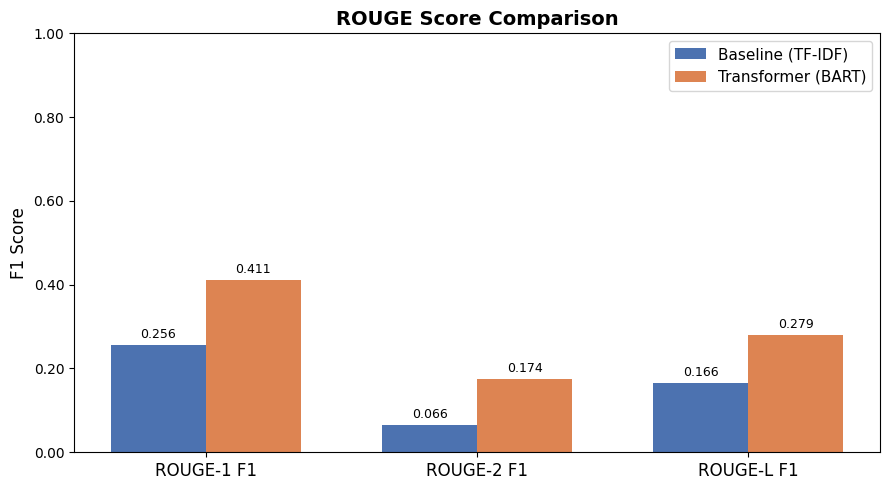

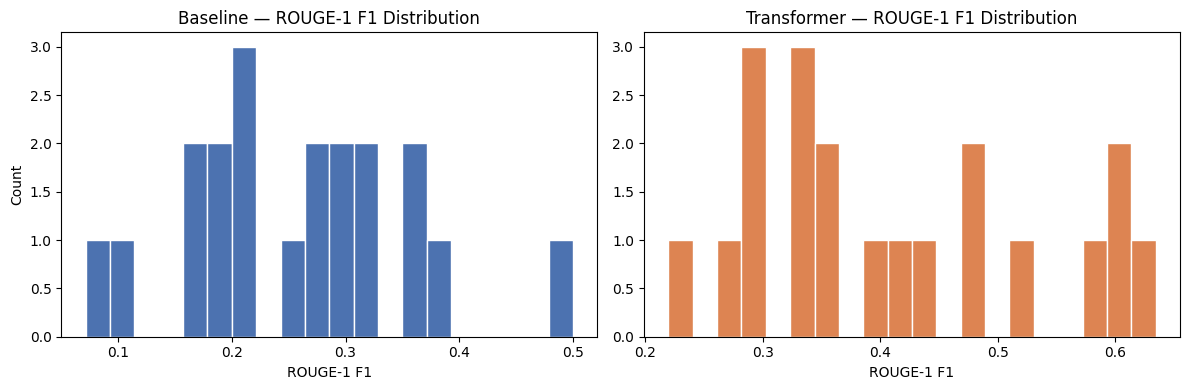

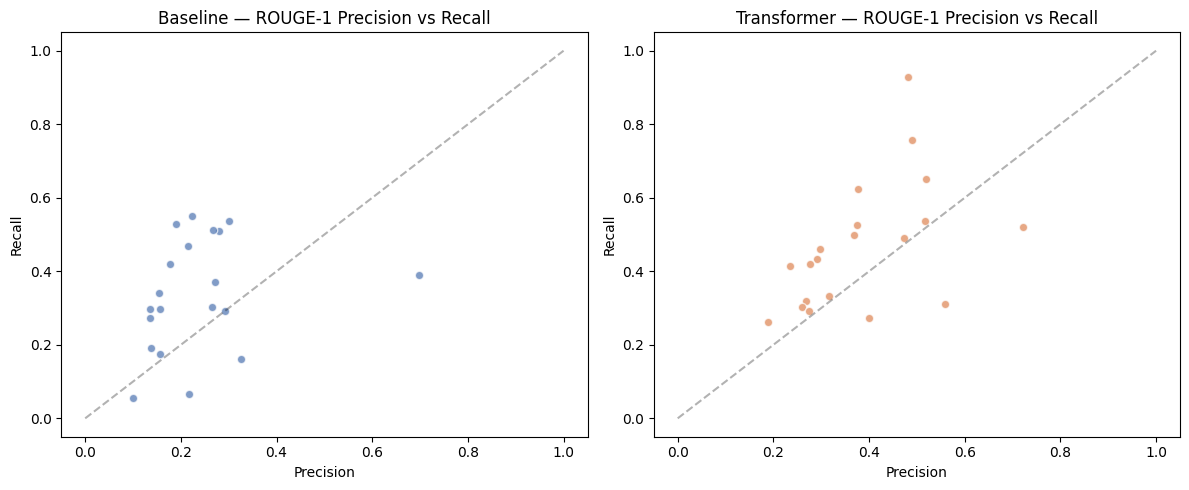

In [136]:

# --- 7a: ROUGE Bar Chart ---
metrics  = ['ROUGE-1 F1', 'ROUGE-2 F1', 'ROUGE-L F1']
base_val = [comparison_df.loc[m, 'Baseline (TF-IDF)']  for m in metrics]
adv_val  = [comparison_df.loc[m, 'Transformer (BART)'] for m in metrics]

x = np.arange(len(metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, base_val, w, label='Baseline (TF-IDF)',  color='#4C72B0')
bars2 = ax.bar(x + w/2, adv_val,  w, label='Transformer (BART)', color='#DD8452')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('ROUGE Score Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2f}"))

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("clean_data/rouge_comparison.png", dpi=120)
plt.show()
# --- 7b: ROUGE-1 Distribution per Article ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(baseline_scores['rouge1_f'],    bins=20, color='#4C72B0', edgecolor='white')
axes[0].set_title('Baseline — ROUGE-1 F1 Distribution')
axes[0].set_xlabel('ROUGE-1 F1'); axes[0].set_ylabel('Count')

axes[1].hist(transformer_scores['rouge1_f'], bins=20, color='#DD8452', edgecolor='white')
axes[1].set_title('Transformer — ROUGE-1 F1 Distribution')
axes[1].set_xlabel('ROUGE-1 F1')

plt.tight_layout()
plt.savefig("clean_data/rouge_distribution.png", dpi=120)
plt.show()


# --- 7c: Precision vs Recall scatter ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(baseline_scores['rouge1_p'], baseline_scores['rouge1_r'],
                alpha=0.7, color='#4C72B0', edgecolors='white')
axes[0].set_xlabel('Precision'); axes[0].set_ylabel('Recall')
axes[0].set_title('Baseline — ROUGE-1 Precision vs Recall')
axes[0].plot([0,1],[0,1], 'k--', alpha=0.3)

axes[1].scatter(transformer_scores['rouge1_p'], transformer_scores['rouge1_r'],
                alpha=0.7, color='#DD8452', edgecolors='white')
axes[1].set_xlabel('Precision'); axes[1].set_ylabel('Recall')
axes[1].set_title('Transformer — ROUGE-1 Precision vs Recall')
axes[1].plot([0,1],[0,1], 'k--', alpha=0.3)

plt.tight_layout()
plt.savefig("clean_data/precision_recall_scatter.png", dpi=120)
plt.show()



In [137]:
print("\n" + "="*70)
print("QUALITATIVE COMPARISON — Sample Articles")
print("="*70)

for i in range(min(3, len(advanced_data))):
    row = advanced_data.iloc[i]
    r1_base = baseline_scores.iloc[i]['rouge1_f']
    r1_adv  = transformer_scores.iloc[i]['rouge1_f']

    print(f"\n[Article {i+1}]")
    print(f"  Article (first 200 chars): {str(row['article'])[:200]}...")
    print(f"\n  Reference Highlights:\n  {row['highlights']}")
    print(f"\n  Baseline Summary (ROUGE-1: {r1_base:.3f}):\n  {row['baseline_summary']}")
    print(f"\n  Transformer Summary (ROUGE-1: {r1_adv:.3f}):\n  {row['advanced_summary']}")
    print("-"*70)



QUALITATIVE COMPARISON — Sample Articles

[Article 1]
  Article (first 200 chars): Former Sen. Rick Santorum, R-Pennsylvania, said this week that the growing threat towards American religious freedom by the government could lead to "Christian persecution," similar to how the oppress...

  Reference Highlights:
  Ex-Pennsylvania Sen. Rick Santorum says Nazi-like religious persecution possible in U.S.
Santorum: Most attacks on religious liberties are a result of government overreach .
Former senator urges people to push back "and defend our liberties"

  Baseline Summary (ROUGE-1: 0.206):
  " While the former presidential candidate did acknowledge that persecution in America is "fairly mild" compared to what's going on in other parts of the world, he warned that it is still dangerous because "it's something that grows over time " "It starts in a gradual erosion," Santorum said "You either conform to what the government says you have to believe in, or you're going to lose certain privile

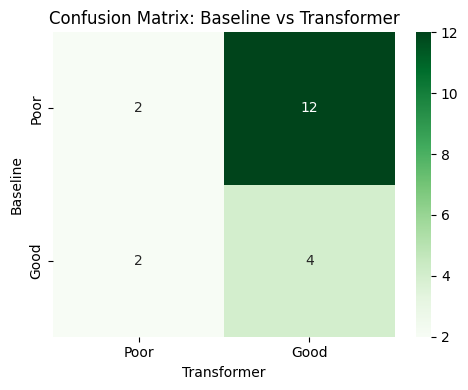

Both Poor       : 2
Baseline Poor  ← BART Good     : 12  
Baseline Good  ← BART Poor     : 2  
Both Good      : 4


In [138]:
# ============================================================
# Confusion Matrix — Baseline vs Transformer
# ============================================================
from sklearn.metrics import confusion_matrix
import seaborn as sns

# كل مقال بياخد label: Good لو ROUGE-1 F1 >= 0.3، Poor لو أقل
def quality_label(score):
    return 'Good' if score >= 0.3 else 'Poor'

base_labels = baseline_scores['rouge1_f'].apply(quality_label)
bart_labels  = transformer_scores['rouge1_f'].apply(quality_label)

labels = ['Poor', 'Good']
cm = confusion_matrix(base_labels, bart_labels, labels=labels)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: Baseline vs Transformer')
plt.xlabel('Transformer')
plt.ylabel('Baseline')
plt.tight_layout()
plt.show()

# طباعة الأرقام بالتفصيل
poor_poor = cm[0][0]
poor_good = cm[0][1]
good_poor = cm[1][0]
good_good = cm[1][1]

print(f"Both Poor       : {poor_poor}")
print(f"Baseline Poor  ← BART Good     : {poor_good}  ")
print(f"Baseline Good  ← BART Poor     : {good_poor}  ")
print(f"Both Good      : {good_good}")